<a href="https://colab.research.google.com/github/nicholas-schwier-class/Computational-Probability-and-Stats-2026/blob/main/Ch2_B_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bernoulli Trial: Probability of a Specific Sequence

Example: THHHH

In [ ]:
# Bernoulli trial: specific ordered sequence

def sequence_probability(sequence, p):
    """
    sequence: string like 'THHHH'
    p: probability of success (H)
    """
    prob = 1.0
    for outcome in sequence:
        if outcome == 'H':
            prob *= p
        else:
            prob *= (1 - p)
    return prob


p = 0.6  # biased coin
sequence = "THHHH"

print("P(THHHH) =", sequence_probability(sequence, p))


Same Probability, Different Order

In [ ]:
sequence1 = "THHHH"
sequence2 = "HTHHH"

print("P(THHHH) =", sequence_probability(sequence1, p))
print("P(HTHHH) =", sequence_probability(sequence2, p))


## Binomial Formula (Manual Implementation)
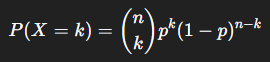

Example: Flipping a Biased Coin

Question: What is the probability of getting exactly 3 heads in 10 flips, if the probability of heads is 0.6?

In [ ]:
import math

def binomial_probability(n, k, p):
    """Compute P(X = k) for a binomial random variable."""
    combinations = math.comb(n, k)
    return combinations * (p ** k) * ((1 - p) ** (n - k))

# Parameters
n = 10       # number of trials
k = 3        # number of successes
p = 0.6      # probability of success

prob = binomial_probability(n, k, p)
print(f"P(X = {k}) = {prob:.5f}")


## Multinomial Distribution (CS Example)
Request types: GET, POST, DELETE

In [ ]:
def multinomial_probability(n_counts, p_values):
    """
    n_counts: list like [5, 3, 2]
    p_values: list like [0.5, 0.3, 0.2]
    """
    n = sum(n_counts)

    coeff = math.factorial(n)
    for count in n_counts:
        coeff //= math.factorial(count)

    prob = coeff
    for count, p in zip(n_counts, p_values):
        prob *= p ** count

    return prob


n_counts = [5, 3, 2]      # GET, POST, DELETE
p_values = [0.5, 0.3, 0.2]

print("Multinomial probability =", multinomial_probability(n_counts, p_values))


Verifying Multinomial with Simulation

In [ ]:
import random

def simulate_requests(trials=100_000):
    outcomes = ['G', 'P', 'D']
    probs = [0.5, 0.3, 0.2]
    success = 0

    for _ in range(trials):
        sample = random.choices(outcomes, probs, k=10)
        if sample.count('G') == 5 and sample.count('P') == 3 and sample.count('D') == 2:
            success += 1

    return success / trials


print("Simulated probability:", simulate_requests())


Scenario

A system routes 1000 incoming requests to 4 servers with different probabilities.

In [ ]:
import numpy as np

requests = 1000
server_probs = [0.4, 0.3, 0.2, 0.1]

load = np.random.multinomial(requests, server_probs)

for i, count in enumerate(load):
    print(f"Server {i+1}: {count} requests")


## Unordered Sampling with Replacement (Stars & Bars)
Airport Shuttle Example
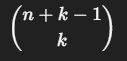

In [ ]:
def stars_and_bars(n, k):
    """
    n: number of categories (hotels)
    k: number of identical items (passengers)
    """
    return math.comb(n + k - 1, k)


n = 5   # hotels
k = 10  # passengers

print("Number of possible distributions:", stars_and_bars(n, k))


In [ ]:
def enumerate_distributions(n, k):
    """
    Enumerate all solutions to x1 + ... + xn = k
    WARNING: use only for small n, k
    """
    solutions = []

    def backtrack(remaining, bins, current):
        if bins == 1:
            solutions.append(current + [remaining])
            return
        for i in range(remaining + 1):
            backtrack(remaining - i, bins - 1, current + [i])

    backtrack(k, n, [])
    return solutions


# Small demo
solutions = enumerate_distributions(3, 4)
print("Number of distributions:", len(solutions))
print("Some solutions:", solutions[:5])
